In [16]:
#!pip install sktime

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sktime.forecasting.compose import make_reduction
from sklearn.ensemble import RandomForestRegressor
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.performance_metrics.forecasting import MeanSquaredError
from sktime.utils.plotting import plot_series

In [2]:
import os
os.chdir("D:/Training/Academy/ML_Python/Datasets/")

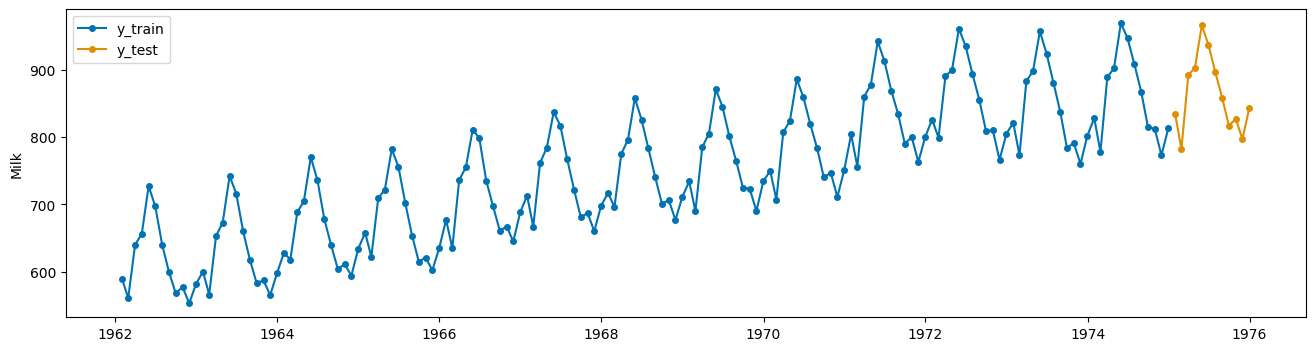

In [3]:
df = pd.read_csv("monthly-milk-production-pounds-p.csv",index_col=0)
df.index = pd.date_range(start='1962-01-01', periods=len(df), freq='ME')
y = df['Milk']
y_train, y_test = temporal_train_test_split(y, test_size=12)
plot_series(y_train, y_test, labels=["y_train", "y_test"])
plt.legend()
plt.show()

In [4]:
fh = np.arange(1, len(y_test) + 1)  # forecasting horizon
regressor = RandomForestRegressor(random_state=26)
forecaster = make_reduction(regressor,window_length=10)
forecaster.fit(y_train)

RecursiveTabularRegressionForecaster(estimator=RandomForestRegressor(random_state=26))

In [5]:
y_pred = forecaster.predict(fh)
rmse = MeanSquaredError(square_root=True)
print(rmse(y_test, y_pred))

23.009066147933954


c:\Users\hp\anaconda3\envs\sktime\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
c:\Users\hp\anaconda3\envs\sktime\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)


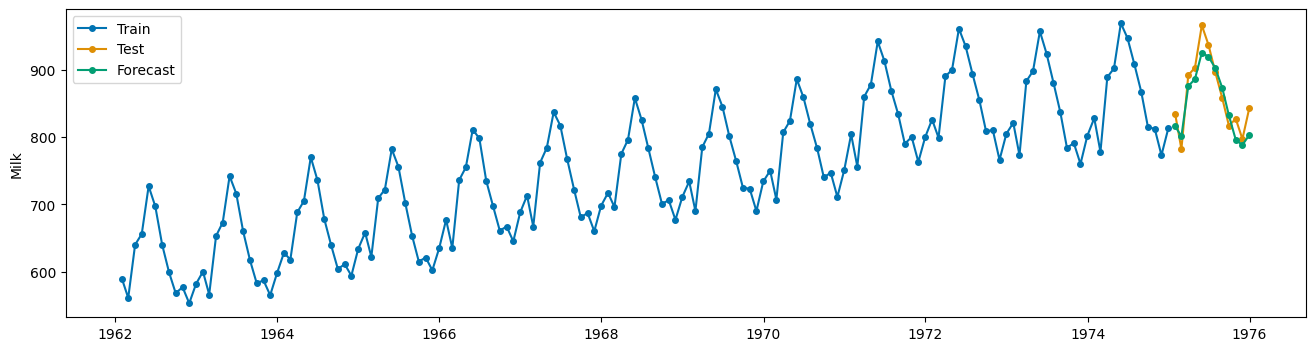

In [6]:
plot_series(y_train,y_test,y_pred , labels=['Train','Test','Forecast'])
plt.show()

#### Basic Grid Search

In [7]:
from sktime.forecasting.compose import make_reduction
from sktime.forecasting.model_selection import ForecastingGridSearchCV,SlidingWindowSplitter

In [8]:
forecaster = make_reduction(regressor, window_length=15, strategy="recursive")
param_grid = {"window_length": [7, 10, 12, 15]}

# We fit the forecaster on an initial window which is 80% of the historical data
# then use temporal sliding window cross-validation to find the optimal hyper-parameters
cv = SlidingWindowSplitter(initial_window=int(len(y_train) * 0.8), window_length=20)
gscv = ForecastingGridSearchCV(
    forecaster, strategy="refit", cv=cv, param_grid=param_grid
)

gscv.fit(y_train)

ForecastingGridSearchCV(cv=SlidingWindowSplitter(initial_window=124,
                                                 window_length=20),
                        forecaster=RecursiveTabularRegressionForecaster(estimator=RandomForestRegressor(random_state=26),
                                                                        window_length=15),
                        param_grid={'window_length': [7, 10, 12, 15]})

In [9]:
print(gscv.best_params_)
print(gscv.best_score_)

{'window_length': 7}
0.029690059449708744


c:\Users\hp\anaconda3\envs\sktime\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
c:\Users\hp\anaconda3\envs\sktime\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)


(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='Milk'>)

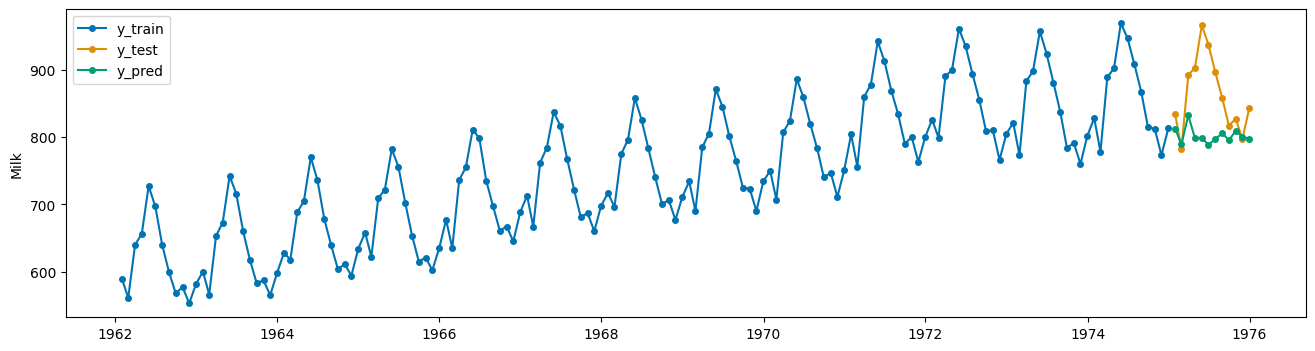

In [10]:
y_pred = gscv.predict(fh)
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

In [11]:
print(rmse(y_test, y_pred))

81.86971743772745


#### Composite Grid Search CV

In [12]:
forecaster = make_reduction(regressor, window_length=15, strategy="recursive")
param_grid = {"window_length": [7,10, 12, 15],
              'estimator__max_features':['auto', 'sqrt', 'log2']}
cv = SlidingWindowSplitter(initial_window=int(len(y_train) * 0.8), window_length=20)
gscv = ForecastingGridSearchCV(
    forecaster, strategy="refit", cv=cv, param_grid=param_grid
)
gscv.fit(y_train)

ForecastingGridSearchCV(cv=SlidingWindowSplitter(initial_window=124,
                                                 window_length=20),
                        forecaster=RecursiveTabularRegressionForecaster(estimator=RandomForestRegressor(random_state=26),
                                                                        window_length=15),
                        param_grid={'estimator__max_features': ['auto', 'sqrt',
                                                                'log2'],
                                    'window_length': [7, 10, 12, 15]})

In [13]:
print(gscv.best_params_)
print(gscv.best_score_)

{'estimator__max_features': 'sqrt', 'window_length': 7}
0.030129462627694996


c:\Users\hp\anaconda3\envs\sktime\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
c:\Users\hp\anaconda3\envs\sktime\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)


(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='Milk'>)

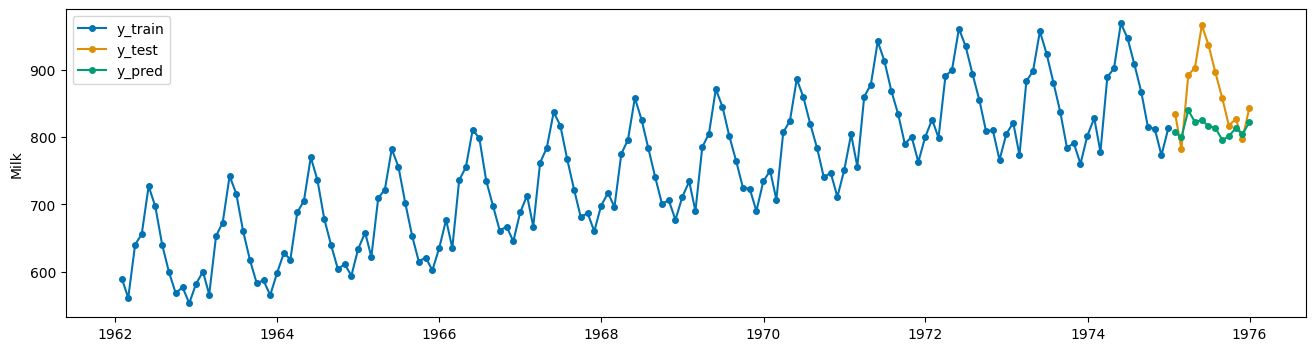

In [14]:
y_pred = gscv.predict(fh)
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

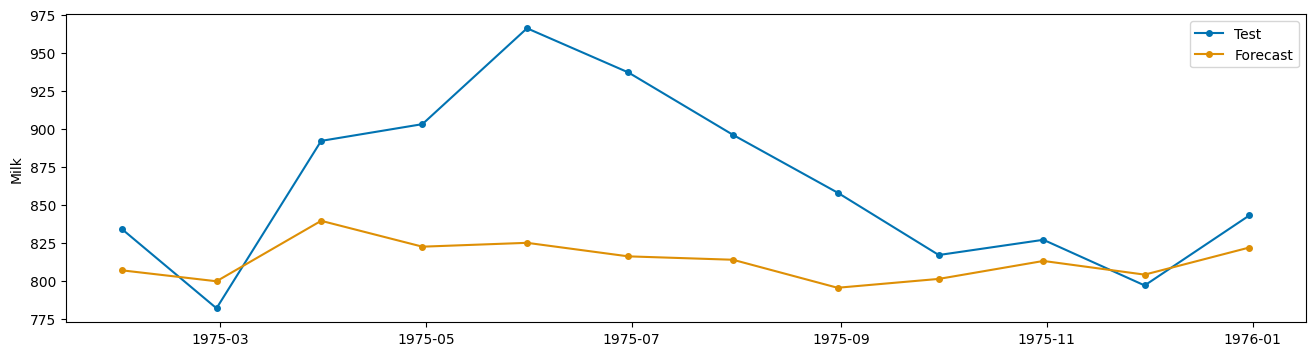

In [15]:
plot_series(y_test,y_pred , labels=['Test','Forecast'])
plt.show()